# College Football Spread Model

Predicting **margin of victory** and comparing it against the **market spread** to look for edges.

The point of this project is not the model architecture. It is the validation discipline:

- **Point-in-time features.** Every feature for a game uses only information available *before* kickoff. No future leakage.
- **Walk-forward validation.** To predict a season, train only on earlier seasons.
- **Graded against the market.** The headline number is model margin error vs the spread's margin error. The market is extremely good, so beating it is hard, and that honesty is the point.

This notebook runs the whole pipeline from cached data and shows the real result.

## 1. Setup

In [1]:
import sys, os
os.chdir(os.path.expanduser("~/Downloads/cfb-spread-model"))
print("Working from:", os.getcwd())
sys.path.insert(0, os.path.abspath("."))   # so `import cfb` works from the repo root

import warnings
# Spurious RuntimeWarnings from Apple Accelerate BLAS on arm64 (numpy 2.x).
# Verified harmless: feature matrix and predictions confirmed finite (0 NaN,
# 0 Inf) before suppressing. Scoped to matmul warnings only.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cfb.features import point_in_time_team_features, build_model_table, FEATURE_COLS, attach_diffs, add_talent_diff
from cfb.model import walk_forward_backtest, grade, backtest_ridge, predict_spread, find_games
from cfb.fetch_data import fetch_talent, fetch_conferences
from cfb.analysis import pockets, matchup_type, P5
from cfb.config import MIN_WEEK, SHRINK_K

pd.set_option("display.max_columns", 50)
print("Imports OK. Feature columns:", FEATURE_COLS)

Working from: /Users/tylerseroczynski/Downloads/cfb-spread-model
Imports OK. Feature columns: ['off_ppa_diff', 'def_ppa_diff', 'success_rate_diff', 'explosiveness_diff', 'scoring_margin_diff', 'home_field']


/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Load the raw data

These two files are produced by `scripts/01_fetch.py` from the CollegeFootballData API.
They are gitignored (data is not committed), so run the fetch once locally to create them.

In [2]:
team_games = pd.read_parquet("data/raw/team_games.parquet")
games = pd.read_parquet("data/raw/games.parquet")

# Dedupe: duplicate game rows were found in review (double-counted in training + MAE)
b1, b2 = len(games), len(team_games)
games = games.drop_duplicates(subset=["game_id"]).reset_index(drop=True)
team_games = team_games.drop_duplicates(subset=["game_id", "team"]).reset_index(drop=True)
print(f"dropped {b1 - len(games)} duplicate games, {b2 - len(team_games)} duplicate team-games")

print(f"team-games: {team_games.shape}")
print(f"games:      {games.shape}")
print(f"seasons:    {sorted(games['season'].unique())}")
team_games.head(3)

dropped 0 duplicate games, 0 duplicate team-games
team-games: (10484, 12)
games:      (13401, 9)
seasons:    [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,game_id,season,week,team,points_for,points_against,off_ppa,def_ppa,off_success_rate,def_success_rate,off_explosiveness,def_explosiveness
0,401282714,2021,1,Illinois,30,22,0.044854,0.320845,0.455882,0.422535,0.966775,1.435771
1,401282714,2021,1,Nebraska,22,30,0.320845,0.044854,0.422535,0.455882,1.435771,0.966775
2,401286187,2021,1,Fresno State,45,0,0.290790,-0.396563,0.493506,0.163934,1.180446,1.126576


## 3. Build point-in-time features

The single rule that makes this honest lives in `cfb/features.py`:

```python
prior_mean = grp[col].transform(lambda s: s.shift(1).expanding().mean())
```

`shift(1)` drops the current game, so a team's feature for a given week is the average of its
**prior** games only. Early-season estimates are shrunk toward a fixed league baseline so that
a team with 3 games played is not trusted as much as one with 10.

In [3]:
features = point_in_time_team_features(team_games, shrink_k=SHRINK_K)
features[["season", "week", "team", "n_prior", "off_ppa_pit", "points_for_pit"]].head(6)

,season,week,team,n_prior,off_ppa_pit,points_for_pit
123,2021,1,Abilene Christian,0,0.000000,28.000000
80,2021,1,Air Force,0,0.000000,28.000000
243,2021,2,Air Force,1,0.074902,29.400000
462,2021,3,Air Force,2,0.054818,28.333333
608,2021,4,Air Force,3,0.107152,30.714286
709,2021,5,Air Force,4,0.137888,30.750000


## 4. Prove there is no future leakage

This is the most important cell in the notebook. The check corrupts every game from a chosen
week onward and confirms that no earlier feature changes. If a future game could move a past
feature, every result below would be worthless.

In [4]:
from tests.test_no_leakage import test_no_future_leak, test_first_game_equals_prior
test_no_future_leak()
test_first_game_equals_prior()

PASS  no future leak (corrupted week >= 7, 192 past team-games checked, all unchanged)
PASS  first game equals prior (32 first-games checked)


## 5. Assemble the model table

One row per game, from the home team's perspective: feature differences, the actual margin,
and the market spread side by side. Filtered to Week 4 and later.

In [5]:
model_table = build_model_table(features, games, min_week=MIN_WEEK)
print(f"{len(model_table)} games (Week {MIN_WEEK}+)")
model_table[["season","week","home_team","away_team","off_ppa_diff",
             "scoring_margin_diff","spread_home","margin"]].head()

3912 games (Week 4+)


,season,week,home_team,away_team,off_ppa_diff,scoring_margin_diff,spread_home,margin
0,2021,4,App State,Marshall,-0.017099,-3.714286,-7.0,1
1,2021,4,Charlotte,Middle Tennessee,0.083609,2.857143,-2.5,3
2,2021,4,Virginia,Wake Forest,0.090103,-3.857143,-3.5,-20
3,2021,4,Syracuse,Liberty,-0.020628,-4.142857,6.5,3
4,2021,4,Fresno State,UNLV,0.178764,22.321429,-30.0,8


## 6. Feature development and backtesting

Everything below is evaluated the same way: train on past seasons only, predict the next (walk-forward). Features tested in order: opponent-adjusted efficiency (Ridge), recent-form weighting, and a 247Sports talent composite. The MAE ladder and pruning check show the verdict -- talent carried real signal; form and opponent adjustment did not survive, and the production model is 7 features. The final section restricts training and evaluation to FBS-vs-FBS games after an audit found ~1,300 FCS games contaminating the sample.

In [6]:
from sklearn.linear_model import Ridge

def add_opponent(team_games):
    """Attach each team-game's opponent by pairing the two rows that share a game_id."""
    pairs = team_games[['game_id','team']]
    m = pairs.merge(pairs, on='game_id', suffixes=('','_opp'))
    m = m[m['team'] != m['team_opp']].rename(columns={'team_opp':'opponent'})
    return team_games.merge(m, on=['game_id','team'], how='left')

def _fit_ratings(prior, alpha):
    # Solve: a team's offensive ppa = its offense rating + the opponent's defense effect.
    # Ridge shrinks toward league average, which handles thin early-season samples.
    O = pd.get_dummies(prior['team']).add_prefix('off_')
    D = pd.get_dummies(prior['opponent']).add_prefix('def_')
    X = pd.concat([O, D], axis=1).fillna(0).astype(float)
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X.values, prior['off_ppa'].astype(float).values)
    return dict(zip(X.columns, model.coef_))

def adjusted_ratings_point_in_time(team_games, alpha=30.0):
    """For each game, ratings computed ONLY from earlier weeks that season (leak-safe)."""
    tg = team_games.dropna(subset=['off_ppa','opponent']).copy()
    rows = []
    for season, sdf in tg.groupby('season'):
        for w in sorted(sdf['week'].unique()):
            prior = sdf[sdf['week'] < w]
            cur = sdf[sdf['week'] == w]
            if len(prior) < 20:                     # too little history to adjust yet
                for _, r in cur.iterrows():
                    rows.append((r['game_id'], r['team'], 0.0, 0.0))
                continue
            coef = _fit_ratings(prior, alpha)
            for _, r in cur.iterrows():
                rows.append((r['game_id'], r['team'],
                             coef.get('off_'+str(r['team']), 0.0),
                             coef.get('def_'+str(r['team']), 0.0)))
    return pd.DataFrame(rows, columns=['game_id','team','adj_off','adj_def'])

def attach_adjusted(model_table, adj):
    """Add opponent-adjusted off/def diffs to the model table."""
    h = adj.rename(columns={'team':'home_team','adj_off':'home_adj_off','adj_def':'home_adj_def'})
    a = adj.rename(columns={'team':'away_team','adj_off':'away_adj_off','adj_def':'away_adj_def'})
    mt = (model_table.merge(h, on=['game_id','home_team'], how='left')
                     .merge(a, on=['game_id','away_team'], how='left'))
    mt['adj_off_diff'] = mt['home_adj_off'] - mt['away_adj_off']
    mt['adj_def_diff'] = mt['home_adj_def'] - mt['away_adj_def']
    return mt

print("opponent-adjustment functions loaded")

opponent-adjustment functions loaded


In [7]:
team_games_opp = add_opponent(team_games)
adj = adjusted_ratings_point_in_time(team_games_opp, alpha=30.0)
model_table_adj = attach_adjusted(model_table, adj)

print("adjusted ratings computed for", len(adj), "team-games")
adj.sort_values("adj_off", ascending=False).head(8)   # your top offenses by adjusted rating

adjusted ratings computed for 10484 team-games


,game_id,team,adj_off,adj_def
7248,401520433,LSU,0.099420,0.022645
7351,401539475,Oregon,0.088574,-0.037096
7204,401520409,LSU,0.086931,0.023304
7246,401524063,Oregon,0.084524,-0.031767
4515,401507652,Incarnate Word,0.083352,-0.031739
4488,401506571,Incarnate Word,0.083246,-0.031219
7114,401540353,South Dakota State,0.077109,-0.040291
6948,401520389,LSU,0.076144,0.019529


In [8]:
find_games("Ohio State", 2024, model_table)

,week,home_team,away_team,spread_home,margin
2745,4,Ohio State,Marshall,-40.0,35
2927,5,Michigan State,Ohio State,23.5,-31
2991,6,Ohio State,Iowa,-17.0,28
3134,7,Oregon,Ohio State,3.5,1
3277,9,Ohio State,Nebraska,-25.0,4
3388,10,Penn State,Ohio State,3.0,-7
3496,11,Ohio State,Purdue,-37.5,45
3595,12,Northwestern,Ohio State,28.0,-24
3707,13,Ohio State,Indiana,-10.5,23
3844,14,Ohio State,Michigan,-20.5,-3


In [9]:
predict_spread("Ohio State", "Indiana", 2024, 13, model_table, FEATURE_COLS)
print()
predict_spread("Ohio State", "Michigan", 2024, 14, model_table, FEATURE_COLS)

Ohio State vs Indiana (2024 wk 13): predicted home margin +2.1

Ohio State vs Michigan (2024 wk 14): predicted home margin +22.8


22.81008676017373

In [10]:
# Recent-form features were tested and cut (no MAE gain -- see the MAE ladder below).
# attach_diffs was promoted to cfb.features for reuse.
mt2 = model_table_adj.copy()
print(f"mt2: {len(mt2)} rows")

mt2: 3912 rows


In [11]:
talent = fetch_talent([2021, 2022, 2023, 2024])
print(f"{len(talent)} team-seasons of talent data (deduped)")

before = len(mt2)
mt2 = add_talent_diff(mt2, talent)
print(f"talent merge: {before} -> {len(mt2)} rows (must be unchanged)")
print(mt2["talent_diff"].describe().round(3))

829 team-seasons of talent data (deduped)
talent merge: 3912 -> 3912 rows (must be unchanged)
count    3912.000
mean        0.079
std         0.682
min        -5.131
25%        -0.166
50%         0.000
75%         0.239
max         5.770
Name: talent_diff, dtype: float64


In [12]:
sets = {
    "base (6)":            FEATURE_COLS,
    "+ opp-adjusted (8)":  FEATURE_COLS + ["adj_off_diff", "adj_def_diff"],
    "+ talent (9)":        FEATURE_COLS + ["adj_off_diff", "adj_def_diff", "talent_diff"],
}

all_feats = sets["+ talent (9)"]
eval_table = mt2.dropna(subset=all_feats + ["margin", "spread_home"]).copy()
print(f"Comparing on {len(eval_table)} identical games\n")

results = {}
for name, cols in sets.items():
    p = backtest_ridge(eval_table, cols)
    p = p.dropna(subset=["spread_home"])
    results[name] = (p["model_margin"] - p["margin"]).abs().mean()

vegas_mae = ((-eval_table["spread_home"]) - eval_table["margin"]).abs().mean()
print("\n=== MAE ladder (lower is better) ===")
for name, v in results.items():
    print(f"  {name:<22} {v:6.3f}   gap to Vegas {v - vegas_mae:+.3f}")
print(f"  {'Vegas closing line':<22} {vegas_mae:6.3f}   <- the bar")

Comparing on 3762 identical games

  2021: skipped (0 prior rows)
  2022: trained 605, predicted 1003
  2023: trained 1608, predicted 1009
  2024: trained 2617, predicted 1145
  2021: skipped (0 prior rows)
  2022: trained 605, predicted 1003
  2023: trained 1608, predicted 1009
  2024: trained 2617, predicted 1145
  2021: skipped (0 prior rows)
  2022: trained 605, predicted 1003
  2023: trained 1608, predicted 1009
  2024: trained 2617, predicted 1145

=== MAE ladder (lower is better) ===
  base (6)               13.400   gap to Vegas +1.347
  + opp-adjusted (8)     13.389   gap to Vegas +1.336
  + talent (9)           13.066   gap to Vegas +1.013
  Vegas closing line     12.053   <- the bar


In [13]:
prune_sets = {
    "base + talent (7)":        FEATURE_COLS + ["talent_diff"],
    "base + adj + talent (9)":  all_feats,
}

print(f"Same {len(eval_table)} games\n")
prune_results = {}
for name, cols in prune_sets.items():
    p = backtest_ridge(eval_table, cols).dropna(subset=["spread_home"])
    prune_results[name] = (p["model_margin"] - p["margin"]).abs().mean()

print("\n=== Pruning check ===")
for name, v in prune_results.items():
    print(f"  {name:<26} {v:6.3f}   gap to Vegas {v - vegas_mae:+.3f}")
print(f"  {'Vegas closing line':<26} {vegas_mae:6.3f}")

Same 3762 games

  2021: skipped (0 prior rows)
  2022: trained 605, predicted 1003
  2023: trained 1608, predicted 1009
  2024: trained 2617, predicted 1145
  2021: skipped (0 prior rows)
  2022: trained 605, predicted 1003
  2023: trained 1608, predicted 1009
  2024: trained 2617, predicted 1145

=== Pruning check ===
  base + talent (7)          13.073   gap to Vegas +1.020
  base + adj + talent (9)    13.066   gap to Vegas +1.013
  Vegas closing line         12.053


In [14]:
FINAL_FEATS = FEATURE_COLS + ["talent_diff"]

final = backtest_ridge(eval_table, FINAL_FEATS).dropna(subset=["spread_home"]).copy()

final["market_margin"] = -final["spread_home"]
final["model_error"] = (final["model_margin"] - final["margin"]).abs()
final["vegas_error"] = (final["market_margin"] - final["margin"]).abs()
final["model_closer"] = final["model_error"] < final["vegas_error"]
final["edge"] = final["model_margin"] - final["market_margin"]

print(f"{len(final)} graded games, "
      f"model closer on {final['model_closer'].mean()*100:.1f}% overall")

  2021: skipped (0 prior rows)
  2022: trained 605, predicted 1003
  2023: trained 1608, predicted 1009
  2024: trained 2617, predicted 1145
3157 graded games, model closer on 42.8% overall


In [28]:
# What drives the prediction: fit the final model once on all seasons and read the weights.
# points_per_1sd = coef * feature std -> margin points moved by a one-standard-deviation
# edge in that factor. Raw coefs aren't comparable across features; these are.
from sklearn.linear_model import Ridge

fit_df = eval_table.dropna(subset=FINAL_FEATS + ["margin"])
m = Ridge(alpha=1.0).fit(fit_df[FINAL_FEATS], fit_df["margin"])

coefs = pd.DataFrame({
    "feature": FINAL_FEATS,
    "coef": m.coef_,
    "std": fit_df[FINAL_FEATS].std().values,
})
coefs["points_per_1sd"] = coefs["coef"] * coefs["std"]
coefs = coefs.sort_values("points_per_1sd", key=abs, ascending=False).round(3)

home_val = fit_df["home_field"].mode()[0]
hfa = m.intercept_ + m.coef_[FINAL_FEATS.index("home_field")] * home_val
print(f"Baseline home edge with all factors even: {hfa:+.2f} points")
coefs

Baseline home edge with all factors even: +3.17 points


,feature,coef,std,points_per_1sd
4,scoring_margin_diff,0.735,9.761,7.174
6,talent_diff,5.357,0.691,3.701
0,off_ppa_diff,27.510,0.096,2.634
3,explosiveness_diff,-15.944,0.102,-1.631
1,def_ppa_diff,-12.031,0.086,-1.040
5,home_field,3.930,0.154,0.607
2,success_rate_diff,7.530,0.044,0.330


In [15]:
confs = fetch_conferences([2022, 2023, 2024])
fbs = set(confs["team"])

for side, key in [("_h", "home_team"), ("_a", "away_team")]:
    sub = confs.rename(columns={"team": key, "conference": "conf" + side})
    final = final.merge(sub, on=["season", key], how="left")

final["matchup"] = final.apply(lambda r: matchup_type(r, fbs), axis=1)

final["line_size"] = pd.cut(final["spread_home"].abs(),
                            bins=[-0.1, 3, 7, 14, 60],
                            labels=["pick-ish (0-3)", "one score (3.5-7)",
                                    "clear fav (7.5-14)", "blowout line (14+)"])
final["week_bucket"] = pd.cut(final["week"],
                              bins=[3, 6, 9, 12, 20],
                              labels=["wk 4-6", "wk 7-9", "wk 10-12", "wk 13+"])
print(final["matchup"].value_counts())

matchup
FCS vs FCS    1301
P5 vs P5       850
G5 vs G5       822
P5 vs G5       119
FBS vs FCS      65
Name: count, dtype: int64


In [16]:
print("=== By matchup type ===");   display(pockets(final, "matchup"))
print("=== By line size ===");      display(pockets(final, "line_size"))
print("=== By week ===");           display(pockets(final, "week_bucket"))
print("=== By season ===");         display(pockets(final, "season"))

=== By matchup type ===


,games,model_mae,vegas_mae,gap,closer_pct
matchup,,,,,
FBS vs FCS,65,14.875,11.338,3.536,41.5
FCS vs FCS,1301,13.228,11.808,1.419,42.0
G5 vs G5,822,13.315,12.360,0.955,43.7
P5 vs G5,119,13.593,11.643,1.950,35.3
P5 vs P5,850,12.390,11.888,0.503,44.2


=== By line size ===


,games,model_mae,vegas_mae,gap,closer_pct
line_size,,,,,
pick-ish (0-3),631,12.999,12.035,0.964,43.6
one score (3.5-7),758,12.611,11.503,1.108,41.7
clear fav (7.5-14),869,12.754,12.343,0.411,45.7
blowout line (14+),899,13.823,11.914,1.909,40.3


=== By week ===


,games,model_mae,vegas_mae,gap,closer_pct
week_bucket,,,,,
wk 4-6,884,13.258,11.573,1.685,40.8
wk 7-9,901,13.016,12.143,0.872,44.5
wk 10-12,983,13.120,12.045,1.075,41.2
wk 13+,389,12.666,12.180,0.486,47.0


=== By season ===


,games,model_mae,vegas_mae,gap,closer_pct
season,,,,,
2022,1003,13.095,11.883,1.212,42.3
2023,1009,13.149,12.089,1.061,41.6
2024,1145,12.985,11.907,1.079,44.2


In [17]:
stab = final.pivot_table(index="matchup", columns="season",
                         values="model_closer", aggfunc="mean") * 100
print("=== Model-closer % by matchup, per season ===")
display(stab.round(1))

stab2 = final.pivot_table(index="line_size", columns="season",
                          values="model_closer", aggfunc="mean", observed=True) * 100
print("=== Model-closer % by line size, per season ===")
display(stab2.round(1))

=== Model-closer % by matchup, per season ===


season,2022,2023,2024
matchup,,,
FBS vs FCS,46.9,38.5,35.0
FCS vs FCS,39.3,41.7,44.2
G5 vs G5,46.1,41.8,43.1
P5 vs G5,51.5,36.1,24.0
P5 vs P5,41.0,42.2,49.3


=== Model-closer % by line size, per season ===


season,2022,2023,2024
line_size,,,
pick-ish (0-3),41.5,42.1,46.3
one score (3.5-7),41.5,40.6,42.9
clear fav (7.5-14),47.3,39.9,49.2
blowout line (14+),38.9,43.9,38.3


In [18]:
view = final.copy()
view["model_spread"] = (-view["model_margin"]).round(1)
view["beat_vegas_by"] = (view["vegas_error"] - view["model_error"]).round(1)

SHOW = ["season", "week", "away_team", "home_team", "matchup",
        "model_spread", "spread_home", "edge", "margin",
        "model_error", "vegas_error", "beat_vegas_by"]
view = view[SHOW].round(1)
print(f"{len(view)} games loaded into viewer")

3157 games loaded into viewer


In [19]:
# 1. Inside the pocket: biggest model-vs-Vegas disagreements in P5 vs P5 games
view[view["matchup"] == "P5 vs P5"].reindex(
    view[view["matchup"] == "P5 vs P5"]["edge"].abs().sort_values(ascending=False).index
).head(15)

,season,week,away_team,home_team,matchup,model_spread,spread_home,edge,margin,model_error,vegas_error,beat_vegas_by
86,2022,4,Vanderbilt,Alabama,P5 vs P5,-20.6,-40.5,-19.9,52,31.4,11.5,-19.9
155,2022,5,Rutgers,Ohio State,P5 vs P5,-19.2,-39.0,-19.8,39,19.8,0.0,-19.8
1214,2023,6,Oklahoma,Texas,P5 vs P5,10.7,-5.5,-16.2,-4,6.7,9.5,2.8
81,2022,4,Iowa,Rutgers,P5 vs P5,-8.2,7.5,15.7,-17,25.2,9.5,-15.7
1011,2023,4,Rutgers,Michigan,P5 vs P5,-9.1,-24.0,-14.9,24,14.9,0.0,-14.9
1093,2023,4,Minnesota,Northwestern,P5 vs P5,-2.9,10.5,13.4,3,0.1,13.5,13.4
1199,2023,5,Washington,Arizona,P5 vs P5,7.0,20.0,13.0,-7,0.0,13.0,13.0
2255,2024,6,Auburn,Georgia,P5 vs P5,-8.3,-21.0,-12.7,18,9.7,3.0,-6.7
765,2022,11,Miami,Georgia Tech,P5 vs P5,10.2,-2.0,-12.2,-21,10.8,23.0,12.2
2180,2024,5,Stanford,Clemson,P5 vs P5,-12.4,-24.0,-11.6,26,13.6,2.0,-11.6


In [20]:
# 3. The model's worst losses -- where Vegas crushed it (know your failure modes)
view.sort_values("beat_vegas_by").head(15)

,season,week,away_team,home_team,matchup,model_spread,spread_home,edge,margin,model_error,vegas_error,beat_vegas_by
2017,2024,4,Stetson,Harvard,FCS vs FCS,3.1,-34.5,-37.6,35,38.1,0.5,-37.6
2078,2024,4,Morehead State,Eastern Kentucky,FCS vs FCS,3.6,-28.0,-31.6,29,32.6,1.0,-31.6
75,2022,4,Davidson,Presbyterian,FCS vs FCS,-0.9,30.0,30.9,-32,32.9,2.0,-30.9
1033,2023,4,Mississippi Valley State,North Carolina Central,FCS vs FCS,2.7,-24.5,-27.2,42,44.7,17.5,-27.2
3133,2024,14,Air Force,San Diego State,G5 vs G5,-20.2,6.0,26.2,-11,31.2,5.0,-26.2
989,2022,14,Valparaiso,New Mexico State,FBS vs FCS,-7.0,-31.5,-24.5,62,55.0,30.5,-24.5
1846,2023,12,Chattanooga,Alabama,FBS vs FCS,-20.8,-44.5,-23.7,56,35.2,11.5,-23.7
2341,2024,7,Butler,Drake,FCS vs FCS,20.5,-2.5,-23.0,10,30.5,7.5,-23.0
2151,2024,5,Sacred Heart,Delaware,FCS vs FCS,-8.0,-31.0,-23.0,49,41.0,18.0,-23.0
2067,2024,4,Mississippi Valley State,Nicholls,FCS vs FCS,-7.2,-30.0,-22.8,66,58.8,36.0,-22.8


In [21]:
# 5. Any team's full history in the backtest
team = "Ohio State"
view[(view["home_team"] == team) | (view["away_team"] == team)].sort_values(["season", "week"])

,season,week,away_team,home_team,matchup,model_spread,spread_home,edge,margin,model_error,vegas_error,beat_vegas_by
85,2022,4,Wisconsin,Ohio State,P5 vs P5,-9.9,-18.5,-8.6,31,21.1,12.5,-8.6
155,2022,5,Rutgers,Ohio State,P5 vs P5,-19.2,-39.0,-19.8,39,19.8,0.0,-19.8
265,2022,6,Ohio State,Michigan State,P5 vs P5,20.6,27.0,6.4,-29,8.4,2.0,-6.4
400,2022,8,Iowa,Ohio State,P5 vs P5,-25.3,-29.5,-4.2,44,18.7,14.5,-4.2
494,2022,9,Ohio State,Penn State,P5 vs P5,16.1,15.5,-0.6,-13,3.1,2.5,-0.6
588,2022,10,Ohio State,Northwestern,P5 vs P5,32.1,37.5,5.4,-14,18.1,23.5,5.4
705,2022,11,Indiana,Ohio State,P5 vs P5,-35.6,-40.5,-4.9,42,6.4,1.5,-4.9
877,2022,12,Ohio State,Maryland,P5 vs P5,23.5,26.0,2.5,-13,10.5,13.0,2.5
929,2022,13,Michigan,Ohio State,P5 vs P5,-4.7,-9.0,-4.3,-22,26.7,31.0,4.3
1086,2023,4,Ohio State,Notre Dame,P5 vs G5,-3.7,3.0,6.7,-3,6.7,0.0,-6.7


In [22]:
# 6. Late-season P5 games only -- the intersection of your two best pockets
view[(view["matchup"] == "P5 vs P5") & (view["week"] >= 13)].sort_values("beat_vegas_by", ascending=False)

,season,week,away_team,home_team,matchup,model_spread,spread_home,edge,margin,model_error,vegas_error,beat_vegas_by
1971,2023,13,Colorado,Utah,P5 vs P5,-10.7,-21.5,-10.8,6,4.7,15.5,10.8
1949,2023,13,Penn State,Michigan State,P5 vs P5,31.7,23.5,-8.2,-42,10.3,18.5,8.2
973,2022,13,Tennessee,Vanderbilt,P5 vs P5,22.2,14.0,-8.2,-56,33.8,42.0,8.2
3139,2024,15,Iowa State,Arizona State,P5 vs P5,-6.0,1.5,7.5,26,20.0,27.5,7.5
3105,2024,14,Arizona State,Arizona,P5 vs P5,14.2,7.5,-6.7,-42,27.8,34.5,6.7
...,...,...,...,...,...,...,...,...,...,...,...,...
3083,2024,14,South Carolina,Clemson,P5 vs P5,-9.6,-3.0,6.6,-3,12.6,6.0,-6.6
3122,2024,14,Florida,Florida State,P5 vs P5,9.9,17.0,7.1,-20,10.1,3.0,-7.1
975,2022,13,Pittsburgh,Miami,P5 vs P5,-3.4,4.0,7.4,-26,29.4,22.0,-7.4
3113,2024,14,NC State,North Carolina,P5 vs P5,-10.0,-2.5,7.5,-5,15.0,7.5,-7.5


In [23]:
import os

def _norm(s):
    return str(s).strip().lower() if s is not None else ""

def fetch_qb_games(years, weeks=range(1, 16)):
    cache = "data/raw/qb_games.parquet"
    if os.path.exists(cache):
        print("loaded from cache")
        return pd.read_parquet(cache)

    rows = []
    for y in years:
        for w in weeks:
            try:
                games_data = _get("/games/players", {"year": y, "week": w,
                                                     "seasonType": "regular"})
            except Exception as e:
                print(f"  {y} wk {w}: fetch failed ({e}), skipping")
                continue
            for g in games_data or []:
                gid = g.get("id")
                for t in g.get("teams", []):
                    team = t.get("team") or t.get("school")
                    for cat in t.get("categories", []):
                        if _norm(cat.get("name")) != "passing":
                            continue
                        for typ in cat.get("types", []):
                            tname = _norm(typ.get("name"))
                            if tname not in ("c/att", "att", "completions/attempts"):
                                continue
                            for ath in typ.get("athletes", []):
                                stat = str(ath.get("stat", "0"))
                                att = stat.split("/")[-1] if "/" in stat else stat
                                try:
                                    att = int(att)
                                except ValueError:
                                    continue
                                rows.append((gid, y, w, team,
                                             ath.get("name"), att))
        print(f"  {y}: done")

    df = pd.DataFrame(rows, columns=["game_id", "season", "week",
                                     "team", "player", "att"])
    df.to_parquet(cache)
    print(f"saved {len(df)} QB-game rows to cache")
    return df

qb = fetch_qb_games([2021, 2022, 2023, 2024])
qb.head()

loaded from cache


,game_id,season,week,team,player,att
0,401282614,2021,1,Notre Dame,Jack Coan,35
1,401282614,2021,1,Florida State,McKenzie Milton,7
2,401282614,2021,1,Florida State,Jordan Travis,19
3,401281946,2021,1,Georgia,JT Daniels,30
4,401281946,2021,1,Clemson,D.J. Uiagalelei,37


In [24]:
def build_qb_out(qb, min_prior_att=25):
    # one row per (team, season, week, player) with attempts that week
    g = (qb.groupby(["season", "team", "week", "player"], as_index=False)["att"].sum())
    g = g.sort_values(["season", "team", "player", "week"])

    # cumulative attempts through PRIOR weeks only
    g["cum_att_prior"] = (g.groupby(["season", "team", "player"])["att"]
                            .transform(lambda s: s.cumsum().shift(1)).fillna(0))

    # weeks each team actually played
    team_weeks = g[["season", "team", "week"]].drop_duplicates()

    # every (player, team-week) combo, so absences appear as rows
    players = g[["season", "team", "player"]].drop_duplicates()
    full = team_weeks.merge(players, on=["season", "team"])
    full = full.merge(g[["season", "team", "week", "player", "att", "cum_att_prior"]],
                      on=["season", "team", "week", "player"], how="left")
    full["att"] = full["att"].fillna(0)
    # a player's prior cumulative attempts carry forward through absent weeks
    full = full.sort_values(["season", "team", "player", "week"])
    full["cum_att_prior"] = (full.groupby(["season", "team", "player"])["cum_att_prior"]
                                 .ffill().fillna(0))

    # primary QB entering each team-week = prior-attempts leader
    idx = full.groupby(["season", "team", "week"])["cum_att_prior"].idxmax()
    primary = full.loc[idx].copy()
    primary["qb_out"] = ((primary["att"] == 0) &
                         (primary["cum_att_prior"] >= min_prior_att)).astype(int)
    return primary[["season", "team", "week", "player", "cum_att_prior", "qb_out"]]

qb_flags = build_qb_out(qb)
print(f"qb_out fires in {qb_flags['qb_out'].mean()*100:.1f}% of team-weeks")
qb_flags[qb_flags["qb_out"] == 1].head(10)

qb_out fires in 11.1% of team-weeks


,season,team,week,player,cum_att_prior,qb_out
91,2021,Akron,6,DJ Irons,87.0,1
96,2021,Akron,7,DJ Irons,87.0,1
90,2021,Akron,13,Zach Gibson,136.0,1
245,2021,Arizona,3,Gunner Cruz,45.0,1
250,2021,Arizona,4,Gunner Cruz,45.0,1
220,2021,Arizona,8,Gunner Cruz,71.0,1
392,2021,Arkansas State,8,James Blackman,172.0,1
394,2021,Arkansas State,9,James Blackman,172.0,1
519,2021,Auburn,12,Bo Nix,282.0,1
523,2021,Auburn,13,Bo Nix,282.0,1


In [25]:
fbs_table = eval_table[eval_table["home_team"].isin(fbs) & eval_table["away_team"].isin(fbs)].copy()
print(f"FBS-only table: {len(fbs_table)} games (was {len(eval_table)})\n")

pf = backtest_ridge(fbs_table, FINAL_FEATS).dropna(subset=["spread_home"]).copy()
pf["model_error"] = (pf["model_margin"] - pf["margin"]).abs()
pf["vegas_error"] = ((-pf["spread_home"]) - pf["margin"]).abs()
pf["model_closer"] = pf["model_error"] < pf["vegas_error"]

print(f"\n=== FBS-trained, FBS-evaluated ===")
print(f"Model MAE:  {pf['model_error'].mean():.3f}")
print(f"Vegas MAE:  {pf['vegas_error'].mean():.3f}")
print(f"Gap:        {pf['model_error'].mean() - pf['vegas_error'].mean():+.3f}")
print(f"Model closer: {pf['model_closer'].mean()*100:.1f}%")

# pocket check on the clean model
pf = pf.merge(final[["season","week","home_team","away_team","matchup"]].drop_duplicates(),
              on=["season","week","home_team","away_team"], how="left")
display(pockets(pf, "matchup"))

FBS-only table: 2376 games (was 3762)

  2021: skipped (0 prior rows)
  2022: trained 585, predicted 584
  2023: trained 1169, predicted 598
  2024: trained 1767, predicted 609

=== FBS-trained, FBS-evaluated ===
Model MAE:  12.872
Vegas MAE:  12.088
Gap:        +0.784
Model closer: 45.1%


,games,model_mae,vegas_mae,gap,closer_pct
matchup,,,,,
G5 vs G5,822,13.140,12.360,0.780,45.7
P5 vs G5,119,14.199,11.643,2.556,32.8
P5 vs P5,850,12.427,11.888,0.540,46.1


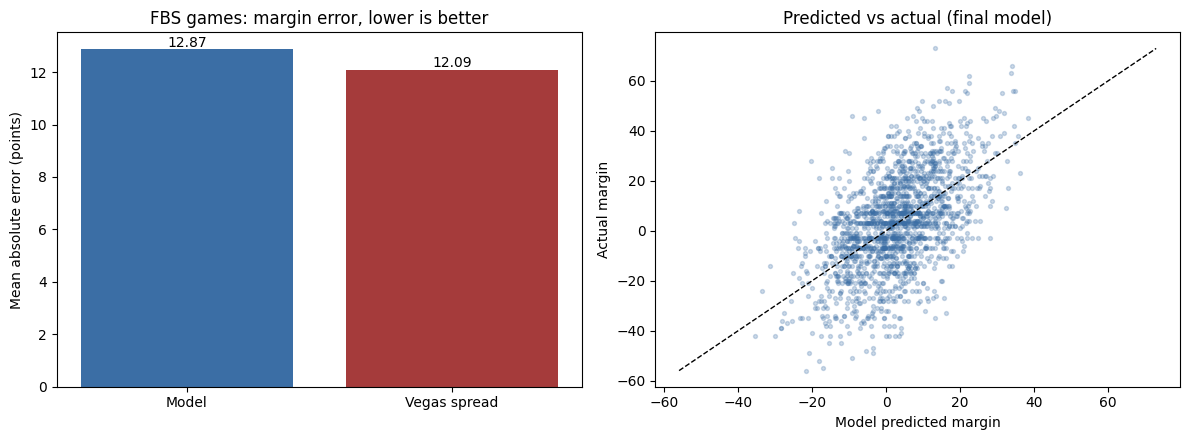

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

m_mae = pf["model_error"].mean()
v_mae = pf["vegas_error"].mean()
axes[0].bar(["Model", "Vegas spread"], [m_mae, v_mae], color=["#3b6ea5", "#a53b3b"])
axes[0].set_ylabel("Mean absolute error (points)")
axes[0].set_title("FBS games: margin error, lower is better")
for i, v in enumerate([m_mae, v_mae]):
    axes[0].text(i, v + 0.1, f"{v:.2f}", ha="center")

axes[1].scatter(pf["model_margin"], pf["margin"], s=8, alpha=0.25, color="#3b6ea5")
lim = [pf["margin"].min(), pf["margin"].max()]
axes[1].plot(lim, lim, "k--", lw=1)
axes[1].set_xlabel("Model predicted margin")
axes[1].set_ylabel("Actual margin")
axes[1].set_title("Predicted vs actual (final model)")

plt.tight_layout()
plt.show()

In [27]:
def dup_report(name, df):
    d = df.duplicated(subset=["season", "week", "home_team", "away_team"]).sum()
    print(f"{name:<18} {len(df):>6} rows, {d} duplicates")

dup_report("model_table", model_table)
dup_report("model_table_adj", model_table_adj)
dup_report("mt2", mt2)
dup_report("eval_table", eval_table)
dup_report("final", final)
dup_report("pf", pf)

model_table          3912 rows, 0 duplicates
model_table_adj      3912 rows, 0 duplicates
mt2                  3912 rows, 0 duplicates
eval_table           3762 rows, 0 duplicates
final                3157 rows, 0 duplicates
pf                   1791 rows, 0 duplicates


## Results

On FBS-vs-FBS games (2022-2024, walk-forward), the 7-feature model lands within **+0.78 points MAE of the Vegas closing line** (12.87 vs 12.09) and is closer to the actual margin than the market in **45.1%** of games -- using only public data, no odds inputs.

The closing line is the strongest public forecast in sports; beating it outright is not a realistic goal for any public-data model. The useful question is *where* the gap narrows. Answer: **P5 vs P5 matchups (gap +0.54, model closer 46.1%)**, stable across all three seasons. Cross-division games (P5 vs G5) are the model's weakest segment.

Tested and cut along the way: recent-form weighting and opponent adjustment (no MAE gain over the talent prior), and a point-in-time QB-availability flag built from participation data (no measurable edge -- the market prices QB absences efficiently). A division-contamination bug and a merge-duplication bug were caught and fixed during review; both are documented in the cells above.